# 01 - LV Scar Exploration

Focus: Core Zone (CZ) only.

Pipeline:
1. Scan + EDA
2. Full-cohort analysis
3. 3-D visualisation (aligned overlay + grid)>

## 0 - Imports & config

In [1]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

def _find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / "lv-scar-segmentation"):
            if (candidate / "src" / "data_loading.py").exists():
                return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the lv-scar-segmentation project root from the current working directory."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loading import scan, diagnose, PatientCase
from src.plot_style import set_tfg_style, save_figure
import pandas as pd

HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_FRAGMENT = 30
MIN_VERTS_ISOMAP = 5
MAX_PLOT_FRAGMENTS = 4

                        # False: only real CZ cases

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
OUT = RESULTS / "M01_scar_exploration"
OUT.mkdir(parents=True, exist_ok=True)

pv.set_jupyter_backend("static")
set_tfg_style()
CLINICAL_CSV          = "C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv"  # path to clinical registry CSV
FLIP_SEPTAL_DIRECTION = False  # set True if RV appears on the LEFT (flips septal rotation)


## 1 - Scan & EDA

Scan external HD for all patient cases. Each case resolves LV shell (endo/epi/myocardium) and tissue surfaces (Core Zone, Border Zone, Scar). EDA checks case counts and missing anatomy.


In [2]:
# ── 1  Scan & EDA ──────────────────────────────────────────────────────────────
all_cases = scan(HD_ROOT)

def has_lv(c):
    return c.lv_dir is not None

def has_cz(c):
    p = c.tissue_surfaces.get("core")
    return p is not None and p.exists()

valid = [c for c in all_cases if has_cz(c)]

_DE_MRI_VARIANTS = ("DE-MRI", "DE-MRI 3D", "DE-MRI 2D")

def _diagnose_case(c):
    base = Path(c.root) / "Basal" / "Data"
    if not base.exists():
        return "no Basal/Data path"
    variants_found = [v for v in _DE_MRI_VARIANTS if (base / v).exists()]
    if not variants_found:
        return f"no DE-MRI folder (tried: {', '.join(_DE_MRI_VARIANTS)})"
    if c.lv_dir is None:
        return f"DE-MRI found ({variants_found[0]}) but no LV subfolder"
    tissue = c.lv_dir / "TISSUE"
    if not tissue.exists():
        return "no TISSUE folder"
    vtks = list(tissue.rglob("*.vtk"))
    if not vtks:
        return "TISSUE exists but no VTK files"
    core = c.tissue_surfaces.get("core")
    if core is None:
        return f"no CZ match in TISSUE (files: {[f.name for f in vtks[:8]]})"
    if core.stat().st_size == 0:
        return "CZ file is empty (0 bytes)"
    return "ok"

_SEP = "─" * 48

# ── Dataset overview (print + CSV) ───────────────────────────────────────────────
print(f"{'DATASET OVERVIEW':^48}")
print(_SEP)
print(f"  {'Year':<6}  {'Total':>7}  {'Has LV':>8}  {'Has CZ':>8}")
print(_SEP)

_overview_rows = []
for year in sorted(set(c.year for c in all_cases)):
    yc    = [c for c in all_cases if c.year == year]
    n_lv_ = sum(1 for c in yc if has_lv(c))
    n_cz_ = sum(1 for c in yc if has_cz(c))
    print(f"  {year:<6}  {len(yc):>7}  {n_lv_:>8}  {n_cz_:>8}")
    _overview_rows.append({"year": year, "total": len(yc), "has_lv": n_lv_, "has_cz": n_cz_})

print(_SEP)
n_tot = len(all_cases)
n_lv  = sum(1 for c in all_cases if has_lv(c))
n_cz  = sum(1 for c in all_cases if has_cz(c))
print(f"  {'TOTAL':<6}  {n_tot:>7}  {n_lv:>8}  {n_cz:>8}")
print(_SEP)
print(f"-> {n_cz} valid cases (with CZ) proceed to analysis.")
_overview_rows.append({"year": "TOTAL", "total": n_tot, "has_lv": n_lv, "has_cz": n_cz})

import csv as _csv_mod
_ov_path = OUT / "eda_dataset_overview.csv"
with open(_ov_path, "w", newline="", encoding="utf-8") as _f:
    _w = _csv_mod.DictWriter(_f, fieldnames=["year","total","has_lv","has_cz"])
    _w.writeheader(); _w.writerows(_overview_rows)
print(f"Saved: {_ov_path}")

# ── Missing cases (print + CSV) ─────────────────────────────────────────────────
_missing_rows = []

def _print_missing(cases, label, status):
    print(f"{label}: {len(cases)}")
    if not cases:
        return
    diagnosed = [(c, _diagnose_case(c)) for c in cases]
    counts = Counter(d for _, d in diagnosed)
    for reason, cnt in counts.most_common():
        ids = [str(c.patient_id) for c, d in diagnosed if d == reason]
        print(f"  {cnt:>3}x  {reason}")
        print(f"        IDs: {', '.join(ids)}")
        for pid in ids:
            _missing_rows.append({"patient_id": pid, "status": status, "reason": reason})

_print_missing([c for c in all_cases if not has_lv(c)], "Without LV dir", "no_lv")
print()
_print_missing([c for c in all_cases if has_lv(c) and not has_cz(c)], "With LV but no CZ", "no_cz")

_miss_path = OUT / "eda_missing_cases.csv"
with open(_miss_path, "w", newline="", encoding="utf-8") as _f:
    _w = _csv_mod.DictWriter(_f, fieldnames=["patient_id","status","reason"])
    _w.writeheader(); _w.writerows(_missing_rows)
print(f"Saved: {_miss_path}  ({len(_missing_rows)} missing cases)")


                DATASET OVERVIEW                
────────────────────────────────────────────────
  Year      Total    Has LV    Has CZ
────────────────────────────────────────────────
  2021         48        12        12
  2022         27        23        23
  2023         47        45        32
  2024         31        31        31
  2025         15         7         7
────────────────────────────────────────────────
  TOTAL       168       118       105
────────────────────────────────────────────────
-> 105 valid cases (with CZ) proceed to analysis.
Saved: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\M01_scar_exploration\eda_dataset_overview.csv
Without LV dir: 50
   35x  no DE-MRI folder (tried: DE-MRI, DE-MRI 3D, DE-MRI 2D)
        IDs: 00021123, 01041694, 02002319, 02011130, 02020684, 03015023, 03031339, 04020449, 05001858, 05027445, 05044223, 06040109, 06050540, 07037693, 07043391, 07044737, 08022556, 18022861, 18042739, 98027481, 980376

## 2 - Full 105-case cohort

No train/test split is created. All valid CZ cases proceed to analysis.

In [3]:
known = list(valid)

print(f"Full cohort: {len(known)} cases")

Full cohort: 105 cases


In [4]:
# ── Load clinical sex for stratified plots ────────────────────────────────────
# clinical_data.py maps SEXO -> sex  (1 = male, 2 = female)
sex_map = {}  # patient_id (str) -> 'M' or 'F'

_csv = CLINICAL_CSV
if _csv is not None:
    try:
        from src.clinical_data import load as _load_clinical
        _cdf = _load_clinical(_csv)
        # after clinical_data.load(): col = "sex" (int: 1=M, 2=F), id col = "patient_id"
        if "sex" in _cdf.columns and "patient_id" in _cdf.columns:
            _sex_raw = {str(row["patient_id"]): int(row["sex"])
                        for _, row in _cdf[["patient_id","sex"]].dropna().iterrows()}
            sex_map  = {pid: ("M" if v == 1 else "F") for pid, v in _sex_raw.items()}
            print(f"Sex loaded: {len(sex_map)} patients  {dict(Counter(sex_map.values()))}")
        else:
            print(f"Expected cols 'patient_id' and 'sex', got: {list(_cdf.columns[:20])}")
    except Exception as _e:
        print(f"Clinical CSV failed: {_e}")
else:
    print("CLINICAL_CSV = None — sex stratification skipped.")


Sex loaded: 94 patients  {'M': 79, 'F': 15}


## 3 - 3-D visualisation

Off-screen PyVista render per case: semi-transparent LV shell + opaque Core Zone (red). Used for visual QC of segmentation quality and scar morphology.


In [5]:
from src.mesh_utils import best_shell as _best_shell, get_cz_mesh
from src.lv_geometry import (
    apply_transform as _apply_transform,
    compute_transform as _compute_transform_base,
    oriented_septal_reference as _base_oriented_septal_reference,
    plane_basis as _plane_basis,
    rotation_about_z as _rotation_about_z,
    rv_reference_pca as _rv_reference_pca,
)


def _oriented_septal_reference(ref):
    return _base_oriented_septal_reference(
        ref,
        flip=globals().get("FLIP_SEPTAL_DIRECTION", False),
    )


def _compute_transform(lv_mesh, align_septum=False):
    return _compute_transform_base(
        lv_mesh,
        align_septum=align_septum,
        flip_septal_direction=globals().get("FLIP_SEPTAL_DIRECTION", False),
    )

print("3-D helpers ready (shared src.mesh_utils/src.lv_geometry).")


3-D helpers ready (shared src.mesh_utils/src.lv_geometry).


### 3b - Per-patient 3-D grid (full cohort)

3-D grid: 100%|██████████| 105/105 [00:37<00:00,  2.78it/s]


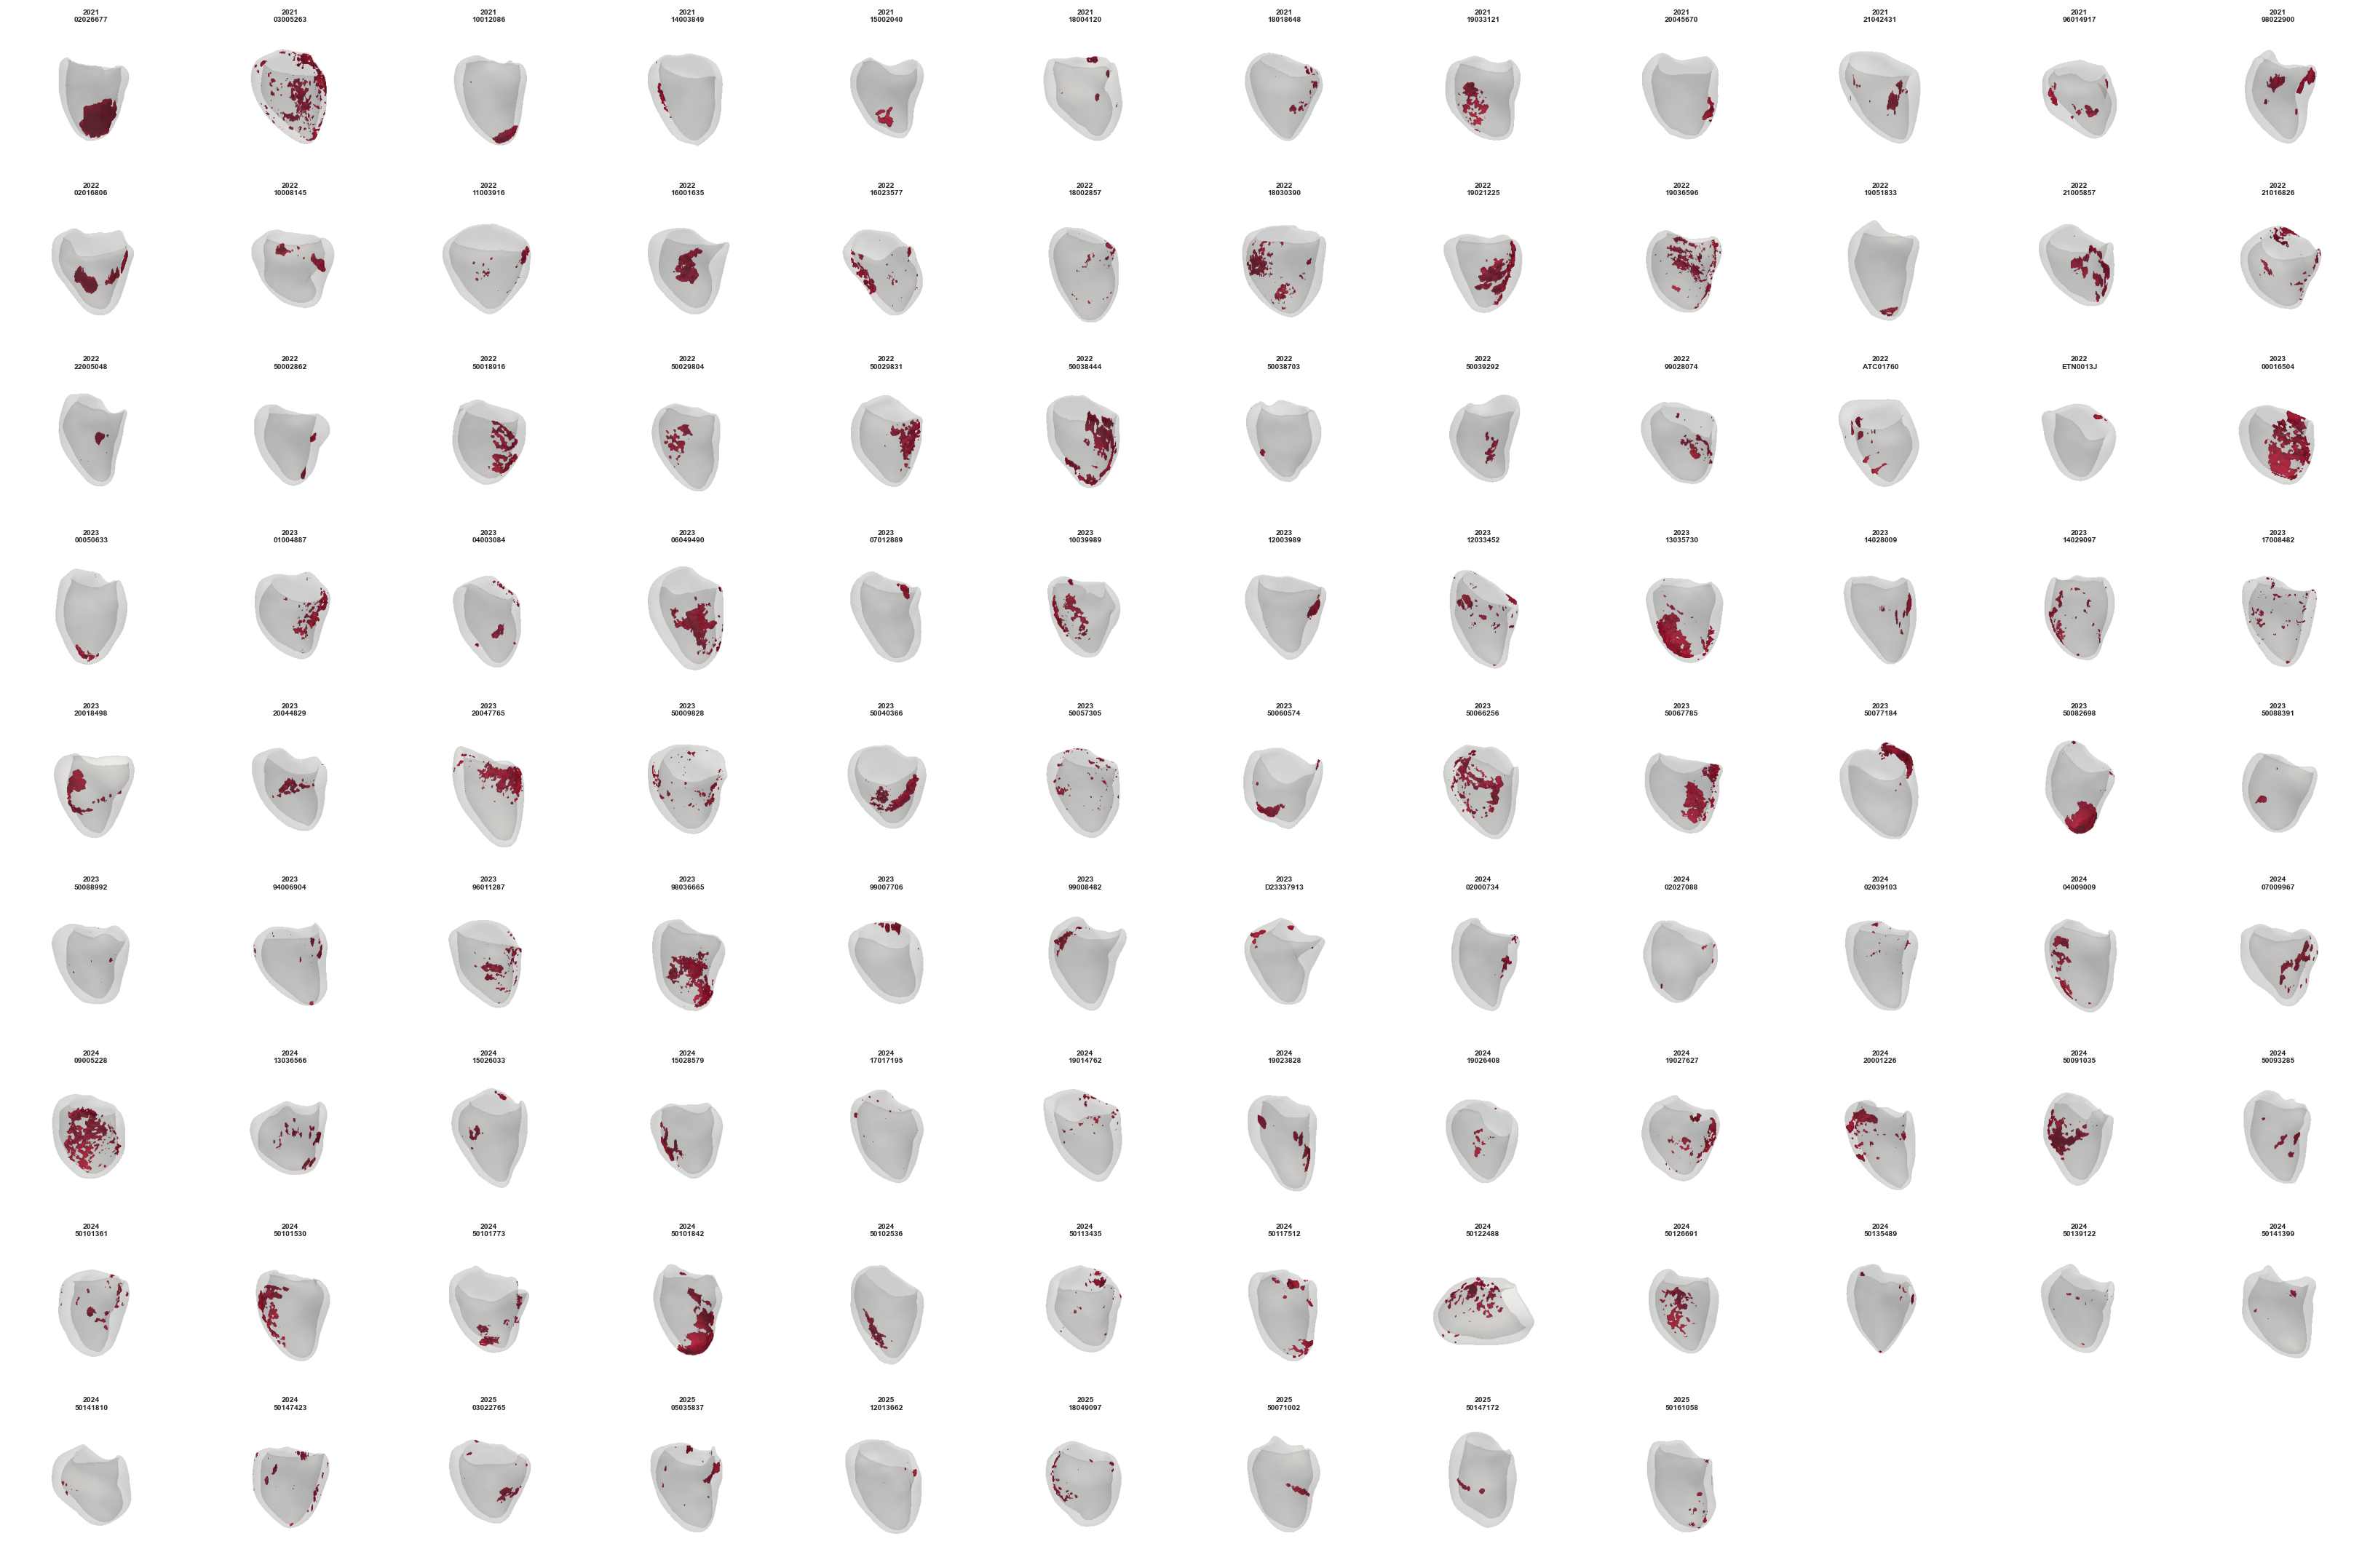

In [6]:
ncols_3d = 12
subset   = list(known)
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc='3-D grid'):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background('white')
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color='crimson', opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f'  skip {case.year}/{case.patient_id}: {e}')

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
# fig.suptitle(f'3-D per-patient grid - {len(thumbnails)} cases',
#              fontsize=12, y=0.995)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis('off')
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    ax.set_title(f'{case.year}\n{case.patient_id}', fontsize=6)
plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.savefig(OUT / '3d_grid_full_cohort.png', bbox_inches='tight')
plt.show()